## __Data Science: Capstone Part 2: Lightning Talk 2__

# Mood-Based Clustering of Spotify Tracks
Data Source: [30000 Spotify Songs (Kaggle)](https://www.kaggle.com/datasets/joebeachcapital/30000-spotify-songs)

# Problem Statement

Spotify tracks carry no explicit "mood" label only audio measurements (energy, valence, danceability, etc.) and metadata like genre. Genre is a weak proxy for mood: a single genre can span calm and intense tracks alike (shown below in EDA), so genre-based playlists don't reliably match a listener's actual mood.

This project applies **unsupervised clustering** to audio features alone no genre, no popularity, no listening history. To discover natural mood groupings directly from a track's "audio DNA" (energy, valence, danceability, acousticness, loudness, tempo, mode). The output is a foundation for a mood-based playlist generator: given any track, map it to its nearest mood cluster and recommend similar tracks from that cluster.

**Success metrics:**
- **Statistical separation** — Silhouette Score and Davies-Bouldin Index across candidate values of K
- **Interpretability** — each cluster's centroid must land in a distinguishable, describable region of the valence-energy space (e.g. "high energy + low valence = Intense/Dark")
- **Qualitative validation** — spot-checking real tracks against their assigned cluster and generated playlist for mood consistency


## Objectives
Key questions guiding this analysis:
- Which audio features carry the most signal about a track's mood?
- Can tracks be separated into distinct, human-interpretable mood clusters using audio features only (no genre, no popularity)?
- How well does existing genre metadata agree with the discovered mood clusters — used only as a validation check, never as a model input?
- What number of clusters (K) best balances statistical cluster separation against a useful, distinct mood taxonomy?


# Data Inspection

## Data Dictionary
| Column | Type | Description |
|---|---|---|
| track_id | string | Spotify track ID |
| track_name | string | Song title |
| track_artist | string | Performing artist |
| track_popularity | int | Spotify popularity score, 0-100 |
| track_album_id | string | Spotify album ID |
| track_album_name | string | Album title |
| track_album_release_date | string (date) | Album release date, 1957-01-01 to 2020-01-29 |
| playlist_name | string | Name of the playlist the track was pulled from |
| playlist_id | string | Spotify playlist ID |
| playlist_genre | string | One of: pop, rap, rock, latin, r&b, edm |
| playlist_subgenre | string | One of 24 subgenres nested under the 6 genres |
| danceability | float | 0.0-1.0, how suitable the track is for dancing |
| energy | float | 0.0-1.0, perceptual intensity/activity |
| key | int | Musical key, 0-11 (pitch class notation, 0=C) |
| loudness | float | Overall loudness in dB |
| mode | int (0/1) | Modality — 1 = major, 0 = minor |
| speechiness | float | 0.0-1.0, presence of spoken words |
| acousticness | float | 0.0-1.0, confidence the track is acoustic |
| instrumentalness | float | 0.0-1.0, predicts absence of vocals |
| liveness | float | 0.0-1.0, likelihood the track was performed live |
| valence | float | 0.0-1.0, musical positiveness (happy vs. sad) |
| tempo | float | Estimated tempo in BPM |
| duration_ms | int | Track length in milliseconds (4,000-517,810) |

**Mood "DNA" features selected for clustering:** `energy`, `valence`, `danceability`, `acousticness`, `loudness`, `tempo`, `mode`. `energy` + `valence` are the two core mood axes (valence-arousal model); the rest add texture (danceability, acousticness) and intensity (loudness, tempo, mode).


In [14]:
# organize your imports in this cell
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Overview
Load and inspect the dataset

In [2]:
df = pd.read_csv(r'C:\Users\jojah\GA_DSB\capstone project\second topic\spotify\spotify_songs.csv')
df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  str    
 1   track_name                32828 non-null  str    
 2   track_artist              32828 non-null  str    
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  str    
 5   track_album_name          32828 non-null  str    
 6   track_album_release_date  32833 non-null  str    
 7   playlist_name             32833 non-null  str    
 8   playlist_id               32833 non-null  str    
 9   playlist_genre            32833 non-null  str    
 10  playlist_subgenre         32833 non-null  str    
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudness         

In [4]:
dna_feats = ['energy', 'valence', 'danceability', 'acousticness', 'loudness', 'tempo', 'mode']
df[dna_feats].describe().T[['min', 'max', 'mean', 'std']]

,min,max,mean,std
energy,0.000175,1.000,0.698619,0.180910
valence,0.000000,0.991,0.510561,0.233146
danceability,0.000000,0.983,0.654850,0.145085
acousticness,0.000000,0.994,0.175334,0.219633
loudness,-46.448000,1.275,-6.719499,2.988436
tempo,0.000000,239.440,120.881132,26.903624
mode,0.000000,1.000,0.565711,0.495671


# Data Cleaning
Missing values, duplicates, and outliers.

In [5]:
# missing values
df.isna().sum().sort_values(ascending=False)

track_name                  5
track_artist                5
track_album_name            5
track_id                    0
track_popularity            0
track_album_id              0
track_album_release_date    0
playlist_name               0
playlist_id                 0
playlist_genre              0
playlist_subgenre           0
danceability                0
energy                      0
key                         0
loudness                    0
mode                        0
speechiness                 0
acousticness                0
instrumentalness            0
liveness                    0
valence                     0
tempo                       0
duration_ms                 0
dtype: int64

In [6]:
# duplicate tracks
print("Duplicate track_ids:", df['track_id'].duplicated().sum())
df = df.drop_duplicates(subset='track_id').reset_index(drop=True)
print("Shape after de-dup:", df.shape)

Duplicate track_ids: 4477
Shape after de-dup: (28356, 23)


In [7]:
# outliers in the mood-DNA features (IQR method)
outlier_summary = {}
for c in dna_feats:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    outlier_summary[c] = int(((df[c] < lo) | (df[c] > hi)).sum())
pd.Series(outlier_summary).sort_values(ascending=False)

acousticness    1911
loudness         837
tempo            494
danceability     257
energy           222
valence            0
mode               0
dtype: int64

**Cleaning decisions:**
- Dropped duplicate `track_id`s (the same track can appear in multiple source playlists).
- No missing-value imputation needed if the dataset comes back clean on `isna()`; if any turn up in `track_album_release_date` or similar metadata columns, those columns aren't used for clustering so they're left as-is rather than dropping rows.
- Outliers in `acousticness`, `loudness`, and `tempo` are kept (they're legitimate quiet/loud/slow/fast tracks, not data errors) but drive the choice of a robust scaler over a standard one ,see Preprocessing.


# Exploratory Data Analysis (EDA)
Answer objectives using visual and statistical insights.

## EDA for Insights
Why genre alone can't stand in for mood.

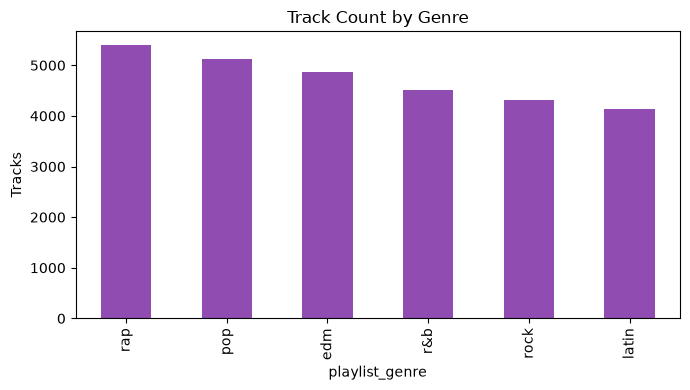

In [8]:
df['playlist_genre'].value_counts().plot(kind='bar', figsize=(7,4), color="#904CB0")
plt.title('Track Count by Genre')
plt.ylabel('Tracks')
plt.tight_layout()
plt.show()

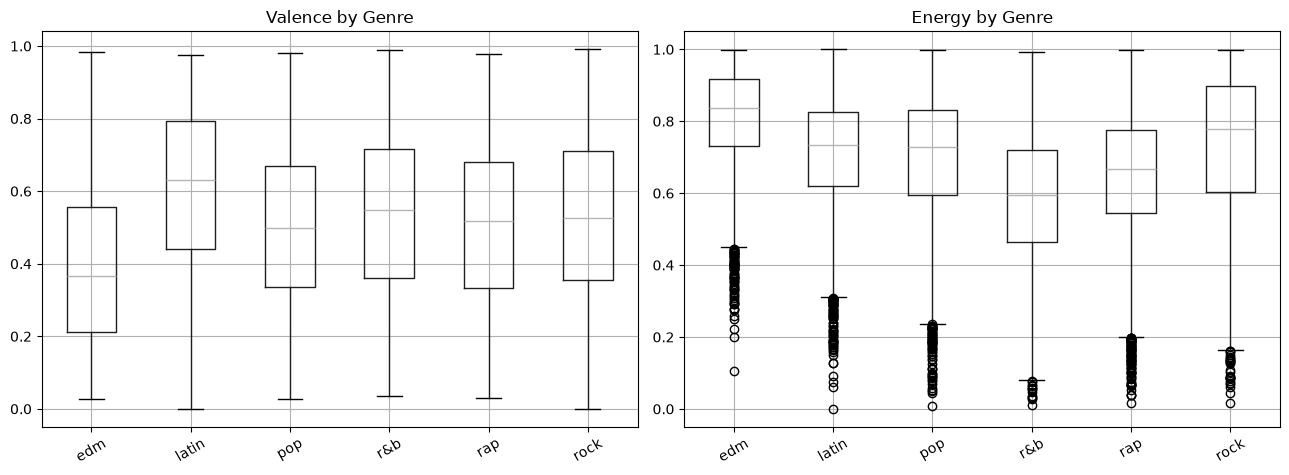

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
for ax, col in zip(axes, ['valence', 'energy']):
    df.boxplot(column=col, by='playlist_genre', ax=ax)
    ax.set_title(f'{col.capitalize()} by Genre')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('')
plt.tight_layout()
plt.show()

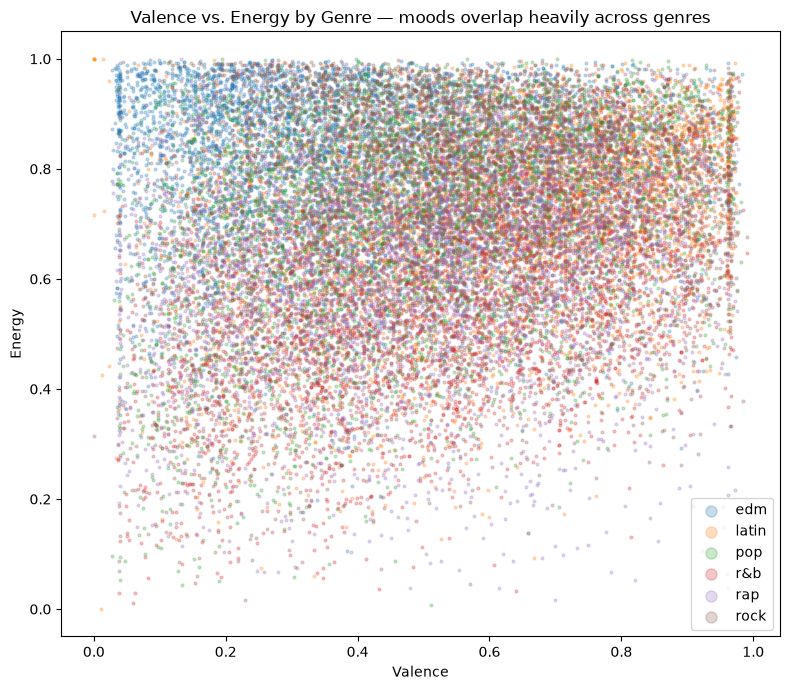

In [10]:
fig, ax = plt.subplots(figsize=(8,7))
for genre, grp in df.groupby('playlist_genre'):
    ax.scatter(grp['valence'], grp['energy'], s=4, alpha=0.25, label=genre)
ax.set_xlabel('Valence'); ax.set_ylabel('Energy')
ax.set_title('Valence vs. Energy by Genre — moods overlap heavily across genres')
ax.legend(markerscale=4, loc='lower right')
plt.tight_layout()
plt.show()

**Takeaway:** every genre's valence/energy boxplot spans a wide range, and the scatter shows genres overlapping almost entirely in valence-energy space rather than forming separate regions. A "chill" track and an "intense" track can both be tagged `pop`. This is the core justification for the project: genre is not a usable mood signal, so mood has to be learned directly from the audio features instead.


## EDA for Modeling
Distributions, scale, and redundancy among the candidate clustering features.

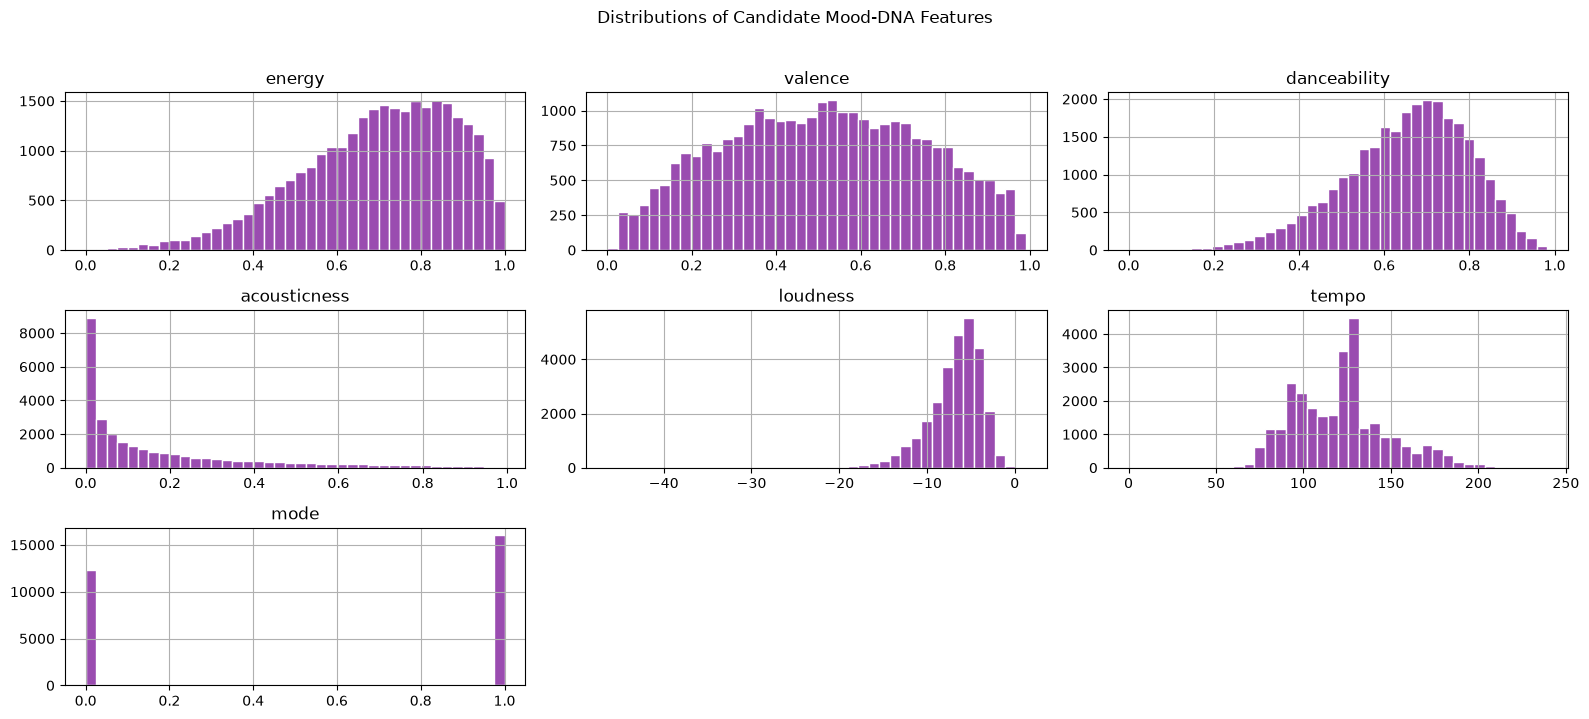

In [16]:
df[dna_feats].hist(bins=40, figsize=(16,7), color="#9A4CB0", edgecolor='white')
plt.suptitle('Distributions of Candidate Mood-DNA Features', y=1.02)
plt.tight_layout()
plt.show()

C:\Users\jojah\AppData\Local\Temp\ipykernel_32532\3594566040.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot([df[c] for c in dna_feats], tick_labels=dna_feats, vert=True)


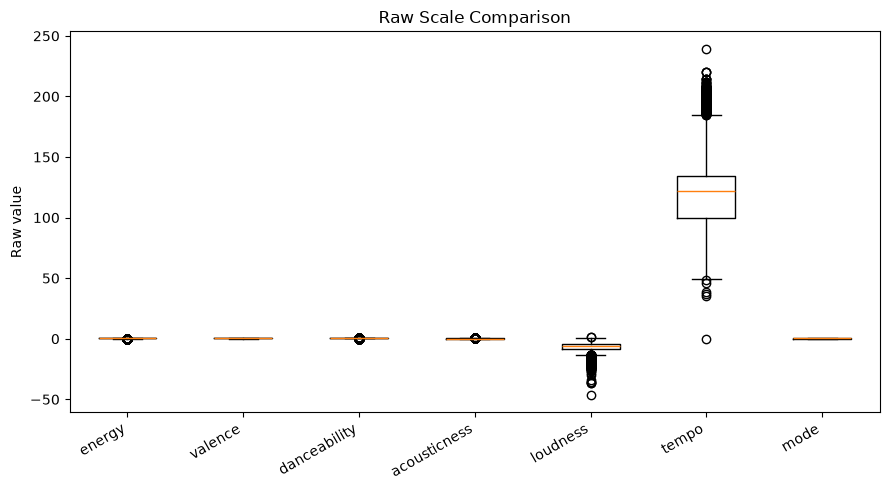

In [13]:
fig, ax = plt.subplots(figsize=(9,5))
ax.boxplot([df[c] for c in dna_feats], tick_labels=dna_feats, vert=True)
ax.set_title('Raw Scale Comparison')
ax.set_ylabel('Raw value')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

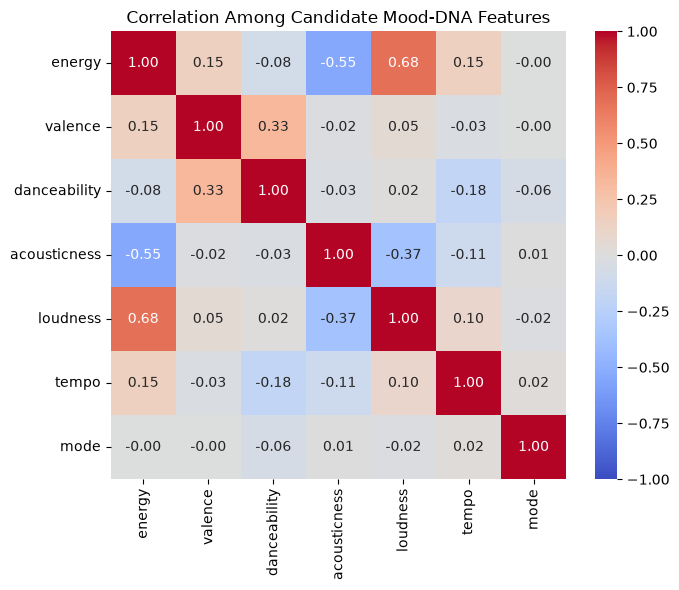

In [15]:

corr = df[dna_feats].corr()
plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Among Candidate Mood-DNA Features')
plt.tight_layout()
plt.show()

**Takeaway:** `loudness` (~-46 to +1 dB) and `tempo` (0-239 BPM) live on completely different scales from the 0-1 features, so Euclidean-distance clustering (K-Means/DBSCAN/Agglomerative) needs the features scaled first, or loudness/tempo will dominate the distance calculation. `energy` and `loudness` are the most correlated pair (~0.68, louder tracks read as more energetic) not severe enough to drop a feature, but worth keeping in mind when interpreting cluster centroids.


# Data Preprocessing & Feature Engineering

- **Feature selection:** the 7 mood-DNA features identified above (`energy`, `valence`, `danceability`, `acousticness`, `loudness`, `tempo`, `mode`). Non-audio columns (IDs, names, popularity, genre, release date) are excluded from the clustering input genre in particular is reserved purely for post-hoc validation.
- **Scaling:** `RobustScaler` rather than `StandardScaler`, since the outlier check above shows real outliers in `acousticness`, `loudness`, and `tempo` that a mean/std-based scaler would be distorted by.
- **Dimensionality reduction:** `PCA` to 2 components, used only for visualization (cluster scatter plots)  clustering itself runs on the full 7-feature scaled space, not the PCA projection, so the reduction never costs the model separating information.
- **No imputation planned** — the missing-value check above is expected to come back clean for the DNA features, if any of the metadata columns show gaps, they aren't used for clustering and won't need to be filled.


# Modelling Approach

- **Models compared:** K-Means (primary,only one with native `.predict()` for new tracks), DBSCAN (density/outlier check, `eps` via k-distance plot), Agglomerative (hierarchical baseline).
- **Choosing K:** swept K=2–10 using Elbow, Silhouette, and Davies-Bouldin. Statistical optimum is a starting point  weighed against whether clusters are interpretable as distinct moods (e.g., overriding a 2-cluster optimum if too coarse, or dropping K if centroids overlap in valence-energy space).
- **Interpretation:** centroids in unscaled feature space, mood labels from relative (median-split, not fixed) energy/valence position, "(Acoustic)" tag when acousticness is high.
- **Evaluation:** Silhouette/Davies-Bouldin scores, cluster size balance, qualitative spot-checks (real tracks, playlist genre-diversity vs. mood-consistency).
- **Deliverable:** `predict_track_mood()`, radar chart vs. cluster average, PCA scatter, `generate_mood_playlist()`.

**Progress:** Full pipeline built and tested. K=4 selected (over silhouette-optimal K=2, too coarse) → four clean, balanced, labeled clusters: Intense/Dark, Upbeat/Hype, Chill/Feel-Good, Chill/Melancholic (Acoustic). Validated against real tracks/playlists.

**Next:** export scaler/model/PCA artifacts, wrap in a backend class, connect to Streamlit/Gradio for the single-track demo.